# Statistical Analysis
In this notebook we will do four statistical analysis.
1. Seasonality Test
2. Correlation and Lag Analysis
3. Time Series Decomposition.
4. Comparative Analysis

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings

# Initial setup
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

warnings.filterwarnings('ignore')

## 1. Seasonality Test
Does Malaria have a seasonal pattern or its is just random variation.

### Null hypothesis (H0)
Cases are evenly distributed across months.

### Alternate hypothesis (H1)
Cases are not evenly distributed (sesonality exists.)

In [4]:
# Load clean data
reports = pd.read_csv('../data/processed/reports_clean.csv')

# Convert data types
reports['report_date'] = pd.to_datetime(reports['report_date'])
reports['case_date'] = pd.to_datetime(reports['case_date'])

category_cols = ['age_group', 'gender']
for col in category_cols:
    reports[col] = reports[col].astype('category')

# Add a month column
reports['month'] = reports['report_date'].dt.month

#### Test for seasonality on all diseases

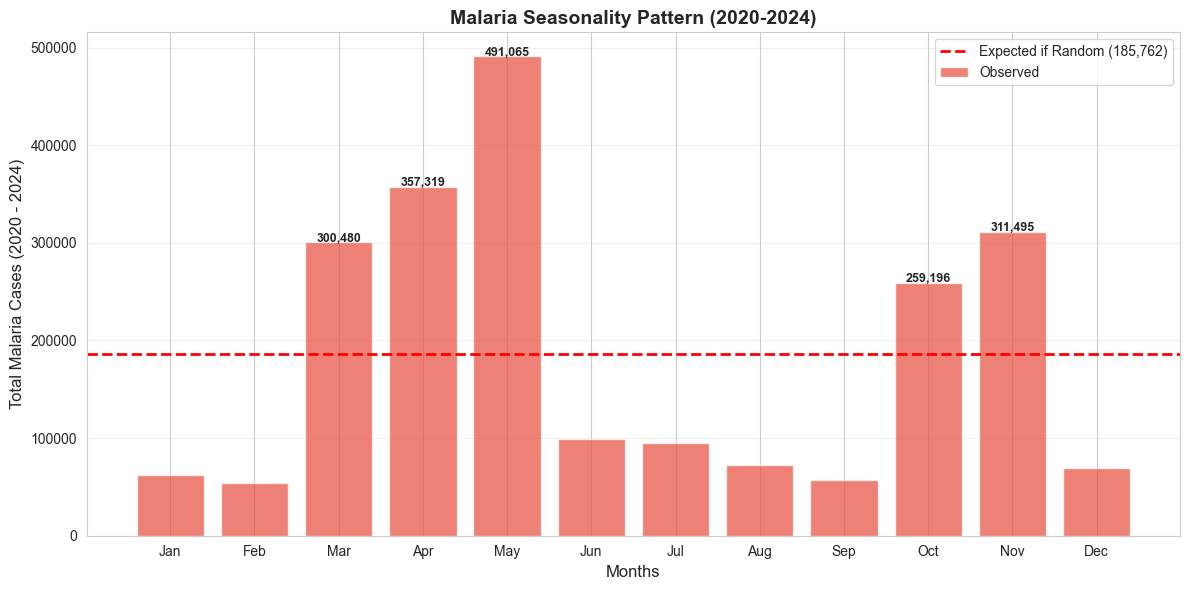

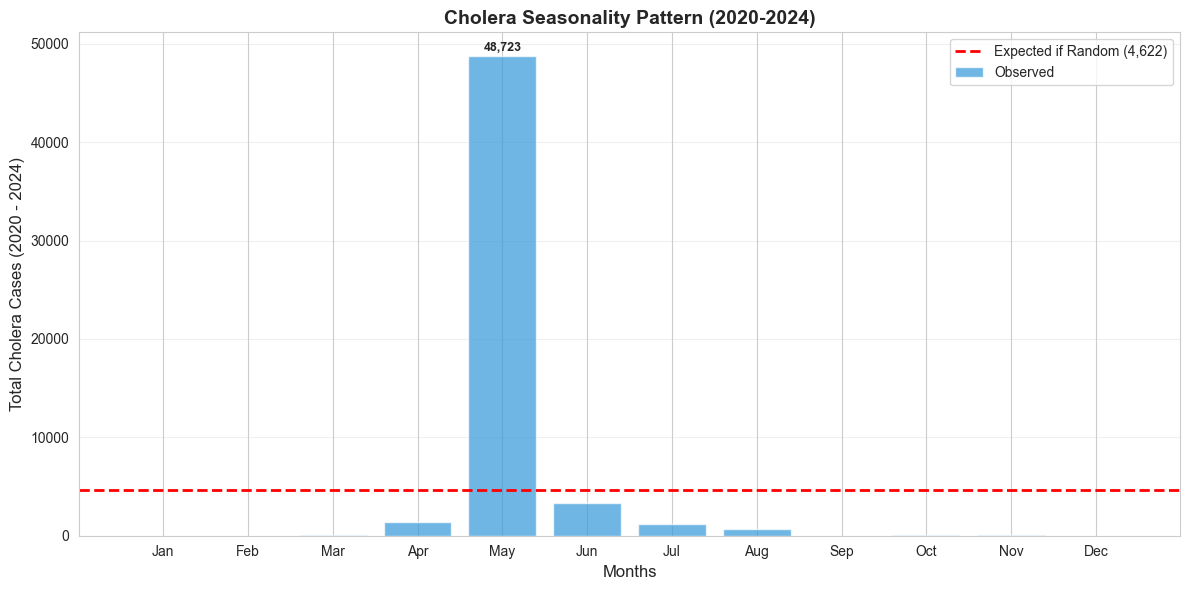

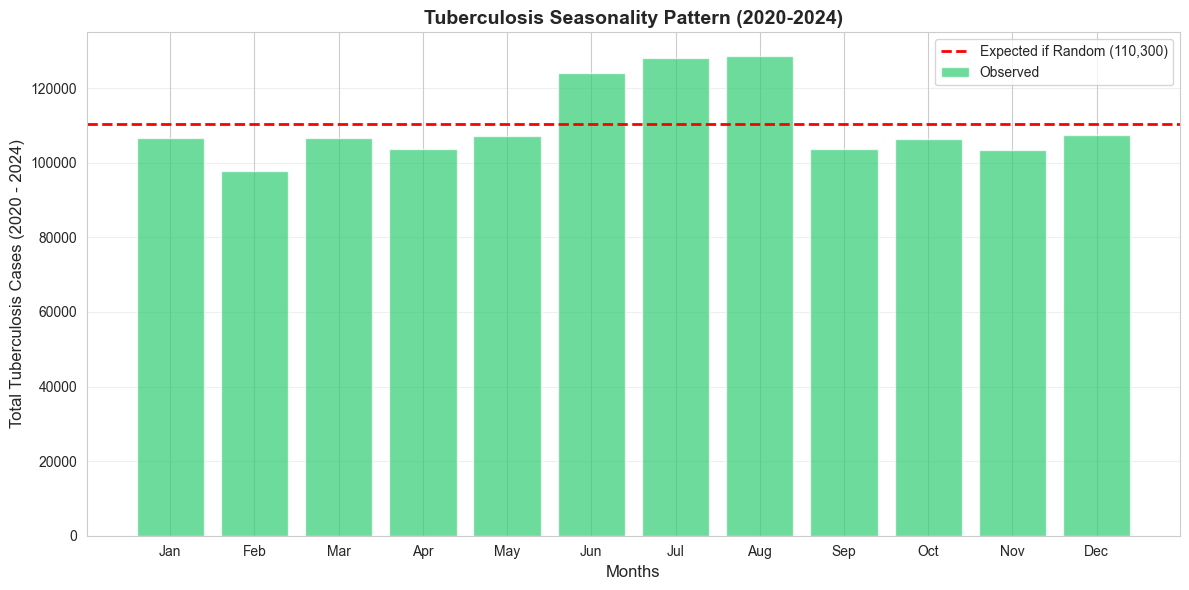

In [5]:
diseases = ['Malaria', 'Cholera', 'Tuberculosis']
colors = ['#e74c3c', '#3498db', '#2ecc71']

results_summary = []

for i, disease in enumerate(diseases):
    disease_data = reports[reports['disease'] == disease]

    observations_per_month = disease_data.groupby('month')['new_cases'].sum()
    total = observations_per_month.sum()
    expected_observations = np.array([total / 12] * 12)
    fig, ax = plt.subplots(figsize=(12, 6))

    months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun','Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    ax.bar(months, observations_per_month.values, color=colors[i], alpha=0.7, label='Observed')

    ax.axhline(y=(total / 12), color='red', linestyle='--', 
            linewidth=2, label=f'Expected if Random ({(total / 12):,.0f})')

    ax.set_xlabel('Months', fontsize=12)
    ax.set_ylabel(f'Total {disease} Cases (2020 - 2024)', fontsize=12)
    ax.set_title(f'{disease} Seasonality Pattern (2020-2024)', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    for i, (month, count) in enumerate(zip(months, observations_per_month.values)):
        if count > (total / 12) * 1.3:
            ax.text(i, count + 500, f'{count:,.0f}', ha='center', fontsize=9, fontweight='bold')


    plt.tight_layout()
    plt.savefig(f'../src/images/{disease}_monthly_trends.png')
    plt.show()

    # chi_square test
    chi2, p_val = stats.chisquare(
        f_obs = observations_per_month.values,
        f_exp = expected_observations
    )

    # Effect size
    cramers = np.sqrt(chi2 / (total * 11))

    results_summary.append({
        'Name of disease': disease,
        'Chi-Square': chi2,
        'P-Value': p_val,
        'Effect size': cramers,
        'Significant': 'Yes' if p_val < 0.05 else 'No',
        'Effect': 'Strong' if cramers > 0.3 else 'Moderate' if cramers > 0.2 else 'Weak' if cramers > 0.1 else 'Negligible'
    })

results_summary_df = pd.DataFrame(results_summary)

## 2. Correlation and Lag Analysis

In this section we will perform weather-disease correlation and lag analysis. We will answers questions like:
- Does rainfall cause malaria?
- How long after rains do cases spike?
- How strong is the effect size?


In [6]:
# Load weather data
weather = pd.read_csv('../data/processed/weather_clean.csv')

# Convert dates
weather['date'] = pd.to_datetime(weather['date'])

# Filter Malaria cases
malaria = reports[reports['disease'] == 'Malaria'].copy()


In [7]:
# Aggregate to national level totals
daily_rainfall = weather.groupby('date')['rainfall_mm'].sum().reset_index()
daily_rainfall.columns = ['date', 'total_rainfall']

daily_malaria = malaria.groupby('report_date')['new_cases'].sum().reset_index()
daily_malaria.columns = ['date', 'total_cases']

# Merge
daily_data = daily_rainfall.merge(daily_malaria, on='date', how='outer')

# Fill missing cases with zero (assume there was no reports)
daily_data['total_cases'] = daily_data['total_cases'].fillna(0)
daily_data['total_rainfall'] = daily_data['total_rainfall'].fillna(0)

# Sort by date
daily_data = daily_data.sort_values('date').reset_index(drop=True)

In [8]:
# Calculate correlation

malaria_correlation = daily_data['total_rainfall'].corr(daily_data['total_cases'])
print(malaria_correlation)

# Lag correlation analysis
max_lag = 40
lag_correlations = []

for lag in range(0, max_lag + 1):
    daily_data[f'rainfall_lag{lag}'] = daily_data['total_rainfall'].shift(lag)

    corr = daily_data[f'rainfall_lag{lag}'].corr(daily_data['total_cases'])
    lag_correlations.append({
        'lag_days': lag,
        'correlation': corr
    })

lag_results = pd.DataFrame(lag_correlations)
optimal_lag = lag_results.loc[lag_results['correlation'].idxmax()]

optimal_lag_days = int(optimal_lag['lag_days'])
if optimal_lag_days < 7:
    print('Interpretation: Cases appear very quickly after rain.')
    print("This is unusual, might indicate pre-exixting infections or poor data reporting.")
elif optimal_lag_days < 14:
    print('Interpretation: Cases appear ~1-2 weeks after rain.')
    print("Inline with mosquito breeding cycle")
elif optimal_lag_days < 21:
    print('Interpretation: Cases appear ~1-2 weeks after rain.')
    print('Matches full transmission cycle + reporting delay.')
else:
    print('Interpretation: Lonf delay (3+ weeks)')



0.6729491245715516
Interpretation: Cases appear very quickly after rain.
This is unusual, might indicate pre-exixting infections or poor data reporting.


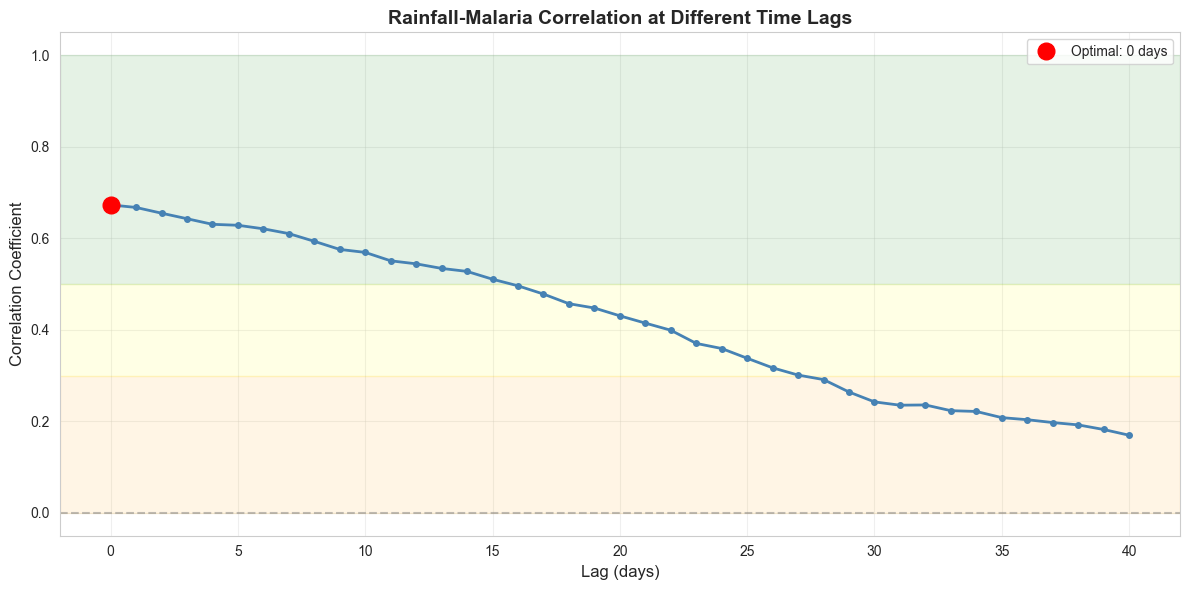

In [9]:
# Visualize Lag Correlations
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(lag_results['lag_days'], lag_results['correlation'], marker='o', linewidth=2, markersize=4, color='steelblue')
optimal_idx = lag_results['correlation'].idxmax()
ax.plot(optimal_lag['lag_days'], optimal_lag['correlation'], "ro", markersize=12, label=f"Optimal: {optimal_lag['lag_days']:.0f} days")
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

ax.set_xlabel('Lag (days)', fontsize=12)
ax.set_ylabel('Correlation Coefficient', fontsize=12)
ax.set_title('Rainfall-Malaria Correlation at Different Time Lags', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

ax.axhspan(0.5, 1.0, alpha=0.1, color='green', label='Strong')
ax.axhspan(0.3, 0.5, alpha=0.1, color='yellow', label='Moderate')
ax.axhspan(0, 0.3, alpha=0.1, color='orange', label='Weak')

plt.tight_layout()
plt.savefig('../src/images/rainfall_malaria_lag.png')
plt.show()

In [10]:
# Statistical significant test
optimal_lag_days = int(optimal_lag['lag_days'])
rainfall_lagged = daily_data[f'rainfall_lag{optimal_lag_days}'].dropna()
cases_aligned = daily_data.loc[rainfall_lagged.index, 'total_cases']

r, p_value = stats.pearsonr(rainfall_lagged, cases_aligned)

print(r, p_value.round(4))

if p_value < 0.001:
    sig_level = "VERY HIGH"
    confidence = ">99.9%"
    conclusion = "The relationship is not random."
elif p_value < 0.01:
    sig_level = "HIGH"
    confidence = '>99%'
    conclusion = "The relationship is very likely real"
elif p_value < 0.05:
    sig_level = 'MODERATE'
    confidence = ">95%"
    conclusion = "The realtionship is likely real"
else:
    sig_level = 'NOT SIGNIFICANT'
    confidence = f"{(1-p_value)*100:.1f}%"
    conclusion = "Cannot prove the a relationship exists"

if abs(r) > 0.7:
    effect = "VERY STRONG"
elif abs(r) > 0.5:
    effect = "STRONG"
elif abs(r) > 0.3:
    effect = "MODERATE"
elif abs(r) > 0.1:
    effect = "WEAK"
else:
    effect = "NEGLIGIBLE"


0.6729491245715516 0.0


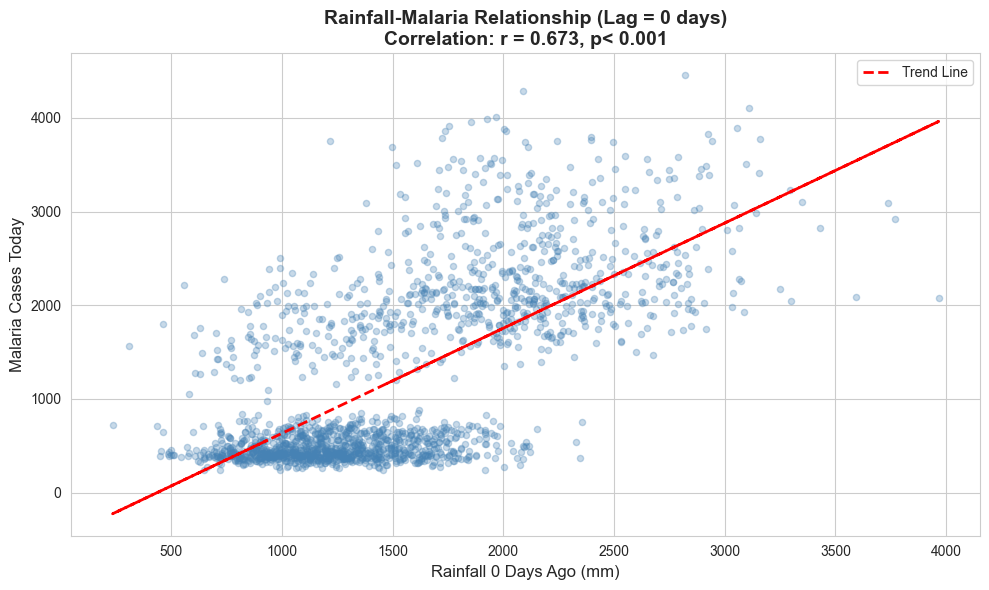

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(rainfall_lagged, cases_aligned, alpha=0.3, s=20, color='steelblue')
z = np.polyfit(rainfall_lagged, cases_aligned, 1)
p = np.poly1d(z)
ax.plot(rainfall_lagged, p(rainfall_lagged), "r--", linewidth=2, label='Trend Line')

ax.set_xlabel(f"Rainfall {optimal_lag_days} Days Ago (mm)", fontsize=12)
ax.set_ylabel('Malaria Cases Today', fontsize=12)
ax.set_title(f'Rainfall-Malaria Relationship (Lag = {optimal_lag_days} days)\n'
             f"Correlation: r = {r:.3f}, p< 0.001",
             fontsize=14, fontweight='bold')

ax.legend()

plt.tight_layout()
plt.savefig('../src/images/rainfall_lag0.png')
plt.show()

In [12]:
# Summary

summary_data = {
    'Metric': [
        'Correlation (Lag 0),',
        f'Correlation (Optimal Lag {optimal_lag_days}d)',
        'Improvement',
        'P-value',
        'Significance',
        'Effect Size',
        'Variance Explained',
        'Optimal Lag'
    ],
    'Value': [
        f"{malaria_correlation}",
        f"{r:.3f}",
        f"{r - malaria_correlation}",
        f"{p_value:.2e}",
        sig_level,
        effect,
        f"{r**2:.3f} ({r**2*100:.1f}%)",
        f"{optimal_lag_days} days"
    ]
}

summary_df = pd.DataFrame(summary_data)

## Time Series Decomposition
1. Is Malaria incresing or decreasing over 5 years?
2. How much variation is trend vs seasonality?
3. Are interventions working?

In [13]:
# Create year_month column for malaria cases
malaria['year_month'] = pd.to_datetime(malaria['report_date']).dt.to_period('M')

# Monthly aggregates
monthly_malaria = malaria.groupby('year_month')['new_cases'].sum().reset_index()
monthly_malaria['year_month'] = monthly_malaria['year_month'].dt.to_timestamp()
monthly_malaria = monthly_malaria.set_index('year_month')
monthly_malaria = monthly_malaria.sort_index()

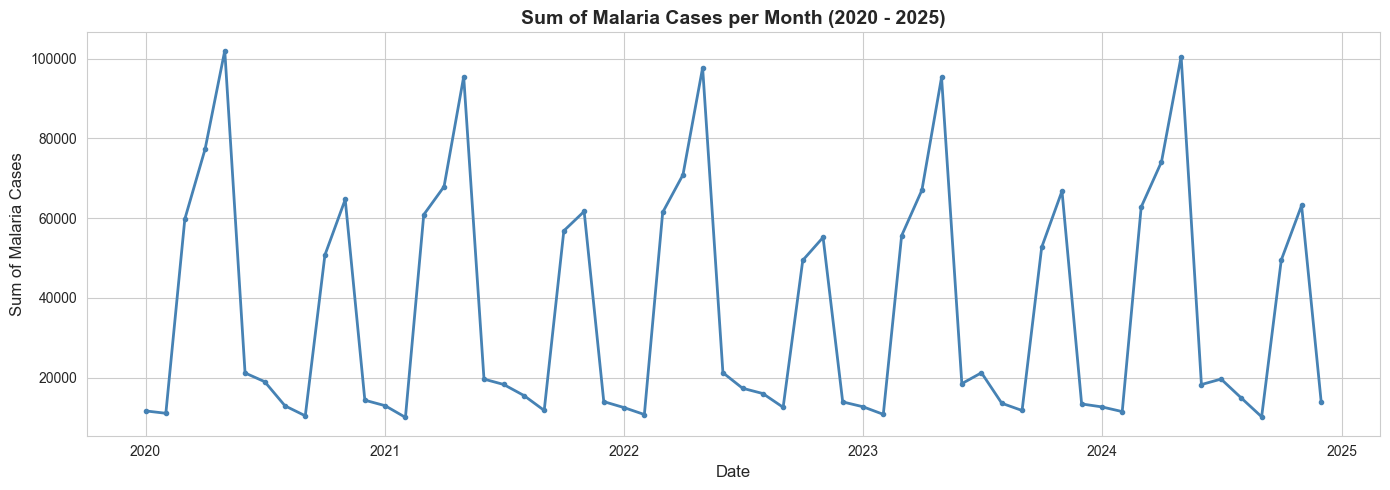

In [14]:
# Visualize Time series

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_malaria.index, monthly_malaria['new_cases'], linewidth=2, color='steelblue', marker='o', markersize=3)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Sum of Malaria Cases', fontsize=12)
ax.set_title('Sum of Malaria Cases per Month (2020 - 2025)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../src/images/malaria_per_month.png')
plt.show()


##### Observation
Seasonal spikes make it hard to see overall trend. Next steps is to decompose to separate trends form seasonality

In [15]:
# Perform decomposition
decomposition = seasonal_decompose(
    monthly_malaria['new_cases'],
    model='additive',
    period=12,
    extrapolate_trend='freq'
)

trend = decomposition.trend.dropna()
seasonal = decomposition.seasonal
residual = decomposition.resid.dropna()

print(f"Trend: {trend.mean():.0f} +/- {trend.std():.0f} cases/month")
print(f"Seasonal: {seasonal.min():.0f} to {seasonal.max():.0f} (swing: {seasonal.max() - seasonal.min():.0f})")
print(f"Residual (noise): +/-{residual.std():.0f} cases")



Trend: 37346 +/- 994 cases/month
Seasonal: -26254 to 61226 (swing: 87480)
Residual (noise): +/-2100 cases


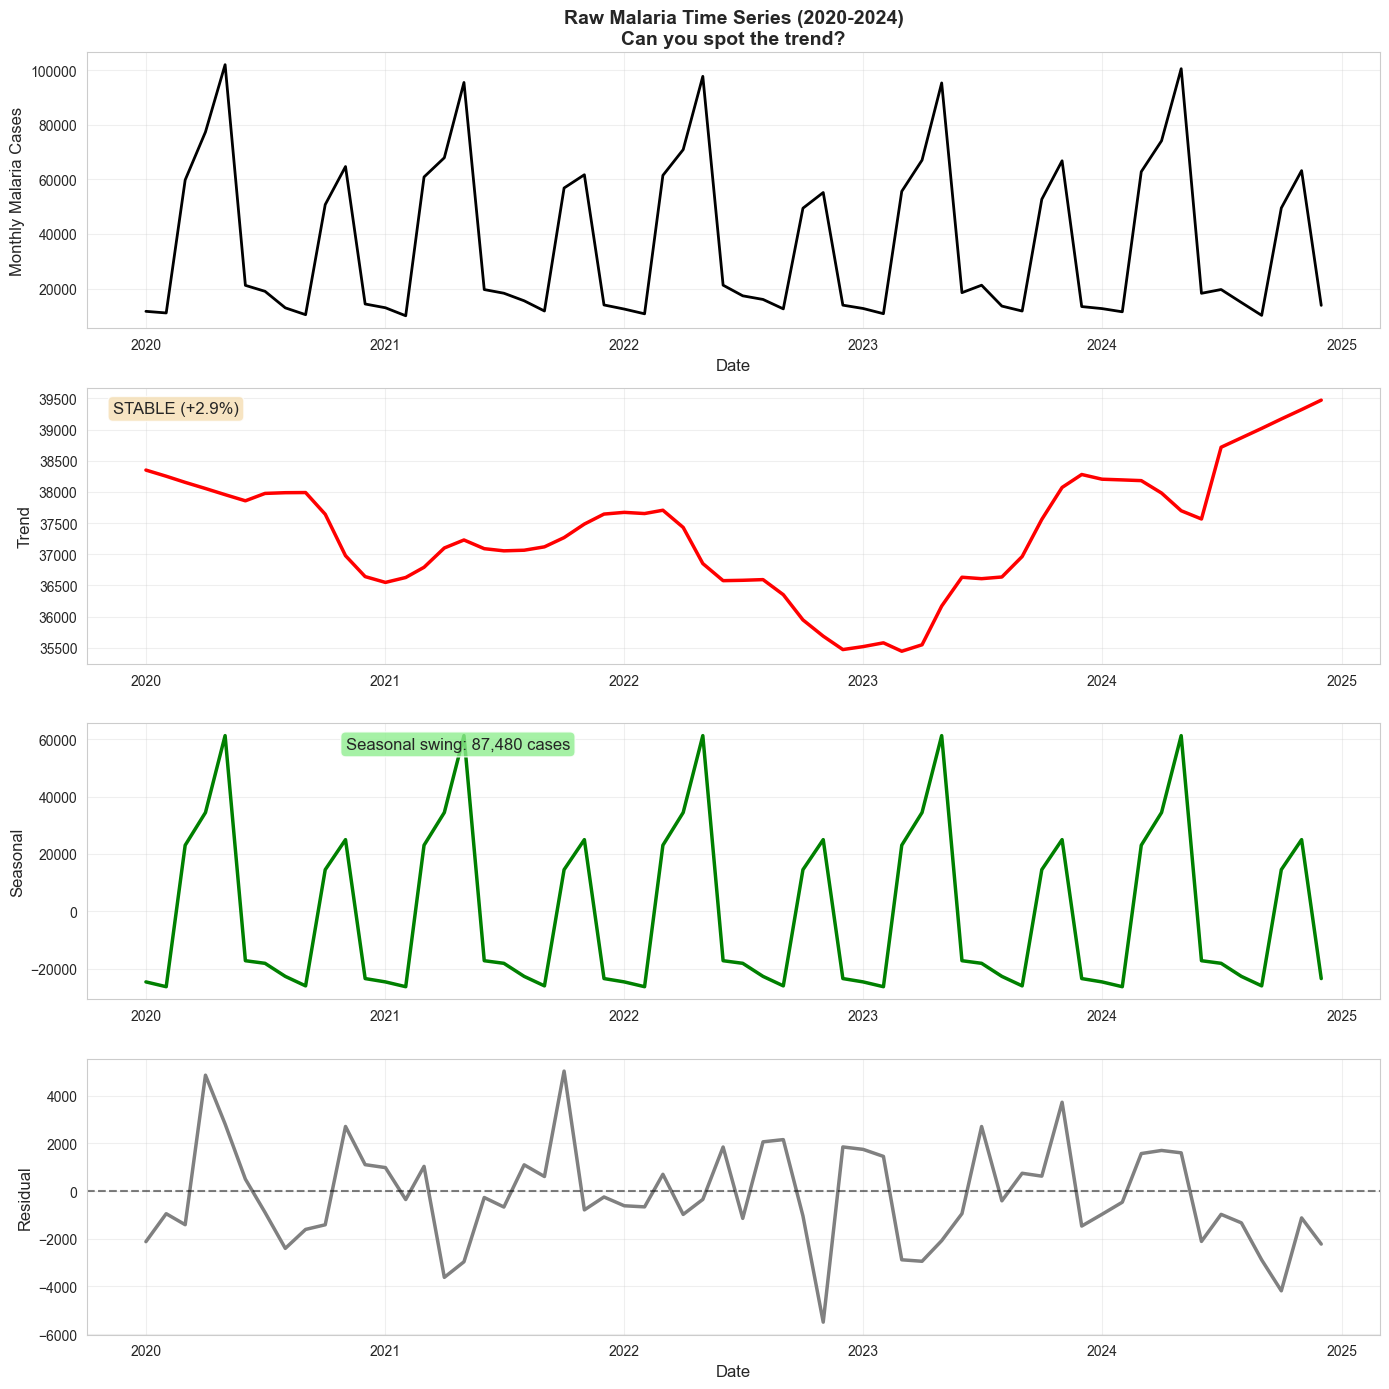

In [16]:
# Visualize Decomposition
fig, axes = plt.subplots(4, 1, figsize=(14, 14))

# Raw plot
axes[0].plot(monthly_malaria.index, monthly_malaria['new_cases'], color='black', linewidth=2)
axes[0].set_xlabel('Date', fontsize=12)
axes[0].set_ylabel('Monthly Malaria Cases', fontsize=12)
axes[0].set_title('Raw Malaria Time Series (2020-2024)\n' + 
                  'Can you spot the trend?',
                  fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Trend plot
axes[1].plot(monthly_malaria.index, trend, color='red', linewidth=2.5)
axes[1].set_ylabel('Trend', fontsize=12)
axes[1].grid(True, alpha=0.3)

trend_start = trend.iloc[0]
trend_end = trend.iloc[-1]
trend_change = ((trend_end - trend_start) / trend_start * 100)
trend_direction = "INCREASING" if trend_change > 5 else "DECREASING" if trend_change < -5 else "STABLE"
axes[1].text(0.02, 0.95, f"{trend_direction} ({trend_change:+.1f}%)",
             transform=axes[1].transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Seasonality plot
axes[2].plot(monthly_malaria.index, seasonal, color='green', linewidth=2.5)
axes[2].set_ylabel('Seasonal', fontsize=12)
axes[2].grid(True, alpha=0.3)

seasonal_range = seasonal.max() - seasonal.min()
axes[2].text(0.2, 0.95, f"Seasonal swing: {seasonal_range:,.0f} cases",
             transform=axes[2].transAxes, fontsize=12, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

# Residual
axes[3].plot(monthly_malaria.index, residual, color='gray', linewidth=2.5)
axes[3].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[3].set_xlabel("Date", fontsize=12)
axes[3].set_ylabel('Residual', fontsize=12)
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../src/images/time_decomposition_all.png')
plt.show()

#### Analyse Trend

In [17]:
# First year average
trend_first = trend.iloc[:12].mean()
# Last year average
trend_last = trend.iloc[:-12].mean()

trend_change_abs = trend_last - trend_first
trend_change_pct = (trend_change_abs / trend_first) * 100
# trend_status = ""
# interpretation = ""
# recommendation = ""

if trend_change_pct > 10:
    trend_status = "INCREASING"
    interpretation = "Malaria situation is worsening despite interventions"
    recommendation = "Urgent review of interventions"
elif trend_change_pct > 5:
    trend_status = "SLIGHTLY INCREASING"
    interpretation = "Malaria situation is slightly worsening"
    recommendation = "Monitor closely and reinforce interventions"
elif trend_change_pct > -5:
    trend_status = "STABLE"
    interpretation = "Malaria situation is stable"
    recommendation = "Maintain current interventions but work on improving to assist in decreasing the numbers."
elif trend_change_pct > -10:
    trend_status = " SLIGHTLY DECREASING"
    interpretation = "Malaria situation is improving"
    recommendation = "Continue current interventions"
else:
    trend_status = "DECREASING"
    interpretation = "Malaria situation is significantly improving"
    recommendation = "Consider scaling up successful interventions"

print(trend_change_pct)

print(f"Trend Status: {trend_status}")
print(f"Interpretation: {interpretation}")
print(f"Recommendation: {recommendation}")

years = round((monthly_malaria.index[-1] - monthly_malaria.index[0]).days / 365)
annual_growth_rate = trend_change_pct / years



-2.0362566555422057
Trend Status: STABLE
Interpretation: Malaria situation is stable
Recommendation: Maintain current interventions but work on improving to assist in decreasing the numbers.


#### Analyse seasonality

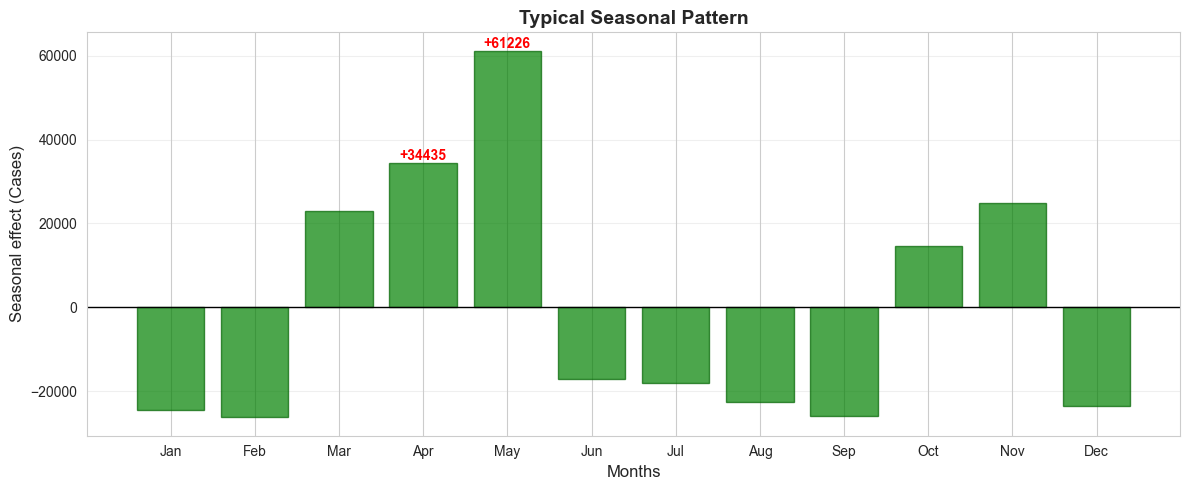

Peak month: May -> 61226
Lowest month: Feb -> -26254
Seasonality explains 99.67 of the overall variation
Trend explains 0.12 of the overall variation
Residual explains 0.52 of the overall variation
Interpretation: Seasonality is he dominant factor. Focus interventions on seasonal timing.


In [18]:
seasonal_pattern = seasonal.iloc[:12].values

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun','Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(months, seasonal_pattern, color='green', alpha=0.7, edgecolor='darkgreen')
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.set_xlabel("Months", fontsize=12)
ax.set_ylabel("Seasonal effect (Cases)", fontsize=12)
ax.set_title("Typical Seasonal Pattern", fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)



# Peak months
for i, (month, value) in enumerate(zip(months, seasonal_pattern)):
    if abs(value) > seasonal_pattern.std():
        color = 'red' if value > 0 else 'blue'
        ax.text(i, value, f'{value:+.0f}', ha='center', va='bottom' if value > 0 else 'top', fontsize=10, fontweight='bold', color=color)

plt.tight_layout()
plt.savefig('../src/images/typical_seasonal_pattern.png')
plt.show()

peak_month_idx = seasonal_pattern.argmax()
lowest_month_idx = seasonal_pattern.argmin()

print(f"Peak month: {months[peak_month_idx]} -> {seasonal_pattern[peak_month_idx]:.0f}")
print(f"Lowest month: {months[lowest_month_idx]} -> {seasonal_pattern[lowest_month_idx]:.0f}")

# Percentage of variation explained by seasonality
total_variance = monthly_malaria['new_cases'].var()
seasonal_var = seasonal.var()
seasonal_pct = round((seasonal_var / total_variance) * 100, 2)
print(f"Seasonality explains {seasonal_pct} of the overall variation")

# Variance decomposition - How much variation comes from other components
trend_var = trend.var()
residual_var = residual.var()

trend_pct = round(trend_var / total_variance * 100, 2)
residual_pct = round(residual_var / total_variance * 100, 2)
print(f"Trend explains {trend_pct} of the overall variation")
print(f"Residual explains {residual_pct} of the overall variation")

# Intepretation
if seasonal_pct > 50:
    print("Interpretation: Seasonality is he dominant factor. Focus interventions on seasonal timing.")
elif trend_pct > 50:
    print("Interpretation: Trend is the dominant factor. Address undelying drivers.")
else:
    print("Interpretation: Mixed factors: Interventions should be seasonal and long term.")

In [20]:
time_summary_data = {
    'Metric': [
        'Trend Status',
        '5-Year Change (%)',
        'Annual Growth Rate (%)',
        'Seaonal Contribution (%0)',
        'Peak Month',
        'Seaonal Swing'
    ],
    'Value': [
        trend_status,
        f"{trend_change_pct:.1f}",
        f"{annual_growth_rate:.1f}",
        f"{seasonal_pct}",
        months[peak_month_idx],
        f"{seasonal_pattern.max() - seasonal_pattern.min():,.0f}"
    ]
}

time_summary_df = pd.DataFrame(time_summary_data)
time_summary_df.head()

,Metric,Value
0,Trend Status,STABLE
1,5-Year Change (%),-2.0
2,Annual Growth Rate (%),-0.4
3,Seaonal Contribution (%0),99.67
4,Peak Month,May
